## Subset + downsample data for analysis in R

In [1]:
import scanpy as sc

import os
import numpy as np
import pandas as pd

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

/home/niklas/miniconda3/envs/niche_fibrosis_env_decoupleR/lib/python3.9/site-packages/setuptools_scm/_integration/setuptools.py:31: RuntimeWarning: 
ERROR: setuptools==59.8.0 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(


Running Scanpy 1.10.3, on 2025-02-26 09:16.


In [2]:
# making sure plots & clusters are reproducible
np.random.seed(42)

In [3]:
## directories
adata_dir = '/mnt/smb/Niklas/GLPG_data_temp/240811_GLPG_annotated.h5ad'
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/liana_results/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig_ccc/'

In [4]:
## load anndata object
adata = sc.read(adata_dir)
adata

AnnData object with n_obs × n_vars = 442439 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type', 'group', 'ChromiumBatch', 'LibraryPrepBatch', 'SeqBatch', 'ashcroft_score', 'body_weight_d0', 'body_weight_d1', 'body_weight_d2', 'body_weight_d3', 'body_weight_d4', 'body_weight_d5', 'body_weight_d6', 'body_weight_d7', 'body_weight_d8', 'body_weight_d9', 'body_weight_d10', 'body_weight_d11', 'body_weight_d12', 'body_weight_d13', 'body_weight_d14', 'body_weight_d15', 'body_weight_d16', 'body_weight_d17', 'body_weight_d18', 'body_weight_d19', 'body_weight_d20', 'body_weight_d21', 'body_weight_min', 'body_weight_max', 'delta_max_body_weight', 'delta_body_weight_d7_10', 'delta_body_weight_d14_d21'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispe

### (1) Subset data

In [5]:
## check
adata.obs.treatment.unique()

['Combo', 'GLPG1205', 'GLPG1690', 'Nintedanib', 'vehicle', 'none']
Categories (6, object): ['none', 'vehicle', 'Nintedanib', 'GLPG1205', 'GLPG1690', 'Combo']

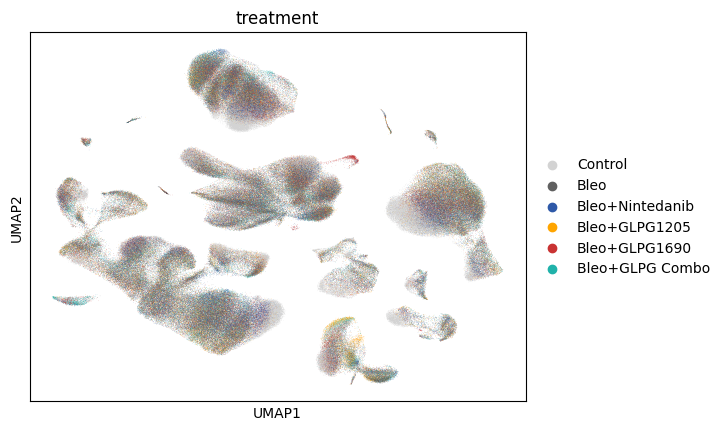

In [6]:
## add better treatment labels
rename_dict = {'none': 'Control',
               'vehicle':'Bleo', 
               'Nintedanib': 'Bleo+Nintedanib',
               'GLPG1205': 'Bleo+GLPG1205',
               'GLPG1690': 'Bleo+GLPG1690',
               'Combo': 'Bleo+GLPG Combo'}
adata.obs['treatment'] = adata.obs['treatment'].map(rename_dict)
treatment_colors = ['#D3D3D3','#606060','#2E59A8','#FFA500','#C93333','#20B2AA']
sc.pl.umap(adata, color=['treatment'], palette=treatment_colors, ncols=1)

In [7]:
## only Ctrl and Bleo
subdata = adata[adata.obs.treatment.isin(['Control','Bleo'])].copy()

In [24]:
subdata = adata.copy()

In [25]:
## check
subdata.obs.cell_type.unique()

['Krt8+ ADI', 'AT1', 'Ciliated', 'AT2 activated', 'Club/Ciliated', ..., 'Mature Neutrophils', 'Immature Neutrophils', 'IFN-primed Neutrophils', 'Basophils', 'Megakaryocytes']
Length: 64
Categories (64, object): ['AT1', 'AT2', 'AT2 activated', 'Krt8+ ADI', ..., 'Themis+ T cells', 'Proliferating T cells', 'NK T cells', 'NK cells']

In [26]:
## only REEF niche cell types
niche_cell_types = ['Eosinophils', 
                    'Vwa1+/Col15a1+ ectopic capillary EC',
                    'Club/Ciliated',
                    'Ciliated',
                    'Basal',
                    'Krt8+ ADI',
                    'Cd8+ T cells',
                    'M2 Macrophages']
subdata = subdata[subdata.obs.cell_type.isin(niche_cell_types)].copy()

In [27]:
## check
subdata.obs.cell_type.unique()

['Krt8+ ADI', 'Ciliated', 'Club/Ciliated', 'Basal', 'Vwa1+/Col15a1+ ectopic capillary EC', 'M2 Macrophages', 'Cd8+ T cells', 'Eosinophils']
Categories (8, object): ['Krt8+ ADI', 'Basal', 'Club/Ciliated', 'Ciliated', 'Vwa1+/Col15a1+ ectopic capillary EC', 'M2 Macrophages', 'Eosinophils', 'Cd8+ T cells']

### (2) Downsample and prepare data
Downsampling to 50 cells per cell type per donor + renormalization

In [28]:
### reproducibility
#rng = np.random.default_rng(42)

In [29]:
### empty array to store selected cell indices
#barcodes = np.array([])  
### maximum number of cells allowed per group
#max_cells = 50  

In [30]:
### important keys
#sample_key = 'sample_name'
#condition_key = 'treatment'
#groupby_key = 'cell_type'

In [31]:
### cell type frequecny per cell type / sample combination
#cell_freqs = adata.obs.rename(columns={'identifier':'count'}).groupby([groupby_key, sample_key])[['count']].count().reset_index()

In [32]:
### downsampling: iterate over cell type / sample combination
#for groupby_val, sample_key_val in cell_freqs[[groupby_key, sample_key]].values:
#    
#    ## get indices for groupby and sample_key
#    cell_idx = adata.obs[(adata.obs[groupby_key] == groupby_val) & (adata.obs[sample_key] == sample_key_val)].index
#    
#    ## if more than max_cells, randomly select max_cells cells
#    if len(cell_idx) > max_cells:
#        ## subsample max_cells
#        cell_idx = rng.choice(cell_idx, max_cells, replace=False)
#    else:
#        ## otherwise keep all cells
#        cell_idx = cell_idx
#        
#    ## merge selected cell indices into barcodes array
#    barcodes = np.concatenate((barcodes, cell_idx))

In [33]:
#subdata = adata[adata.obs.index.isin(barcodes)].copy()

In [34]:
#subdata

In [35]:
#print(f'Before subsampling: {adata.shape[0]} cells in total')
#print(f'After subsampling: {subdata.shape[0]} cells in total')
#print(f'Summary: subsampling reduced total cell counts by factor: {round(subdata.shape[0]/adata.shape[0],2)}')

In [36]:
subdata.X = subdata.layers['counts'].copy()
print(f"Max count: {subdata.layers['counts'].max()}")

Max count: 17636.0


In [37]:
sc.pp.normalize_total(subdata, target_sum=1e4)
sc.pp.log1p(subdata)

normalizing counts per cell
    finished (0:00:00)


In [38]:
## delete unecessary metadata
del subdata.obs['preprocessing_cluster']
del subdata.obs['size_factors']
del subdata.obs['S_score']
del subdata.obs['G2M_score']
del subdata.obs['phase']
del subdata.obs['cluster_03']
del subdata.obs['louvain_1']
del subdata.obs['louvain_2']
del subdata.obs['body_weight_d1']
del subdata.obs['body_weight_d2']
del subdata.obs['body_weight_d3']
del subdata.obs['body_weight_d4']
del subdata.obs['body_weight_d5']
del subdata.obs['body_weight_d6']
del subdata.obs['body_weight_d7']
del subdata.obs['body_weight_d8']
del subdata.obs['body_weight_d9']
del subdata.obs['body_weight_d11']
del subdata.obs['body_weight_d12']
del subdata.obs['body_weight_d13']
del subdata.obs['body_weight_d14']
del subdata.obs['body_weight_d15']
del subdata.obs['body_weight_d16']
del subdata.obs['body_weight_d17']
del subdata.obs['body_weight_d18']
del subdata.obs['body_weight_d19']
del subdata.obs['body_weight_d20']
del subdata.layers['unsouped_counts']

In [39]:
subdata

AnnData object with n_obs × n_vars = 73954 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'doublet_scores', 'n_genes', 'cell_type', 'group', 'ChromiumBatch', 'LibraryPrepBatch', 'SeqBatch', 'ashcroft_score', 'body_weight_d0', 'body_weight_d10', 'body_weight_d21', 'body_weight_min', 'body_weight_max', 'delta_max_body_weight', 'delta_body_weight_d7_10', 'delta_body_weight_d14_d21'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'ChromiumBatch_colors', 'GLPG_annotation_colors', 'LibraryPrepBatch_colors', 'SeqBatch_colors', 'cell_type_colors', 'condition_colors', 'hvg', 'louvain_1_colors', 'neighbors', 'pca', 'time_point_colors', 'treatment_colors', 'treatment_time_colors', 'umap', 'log1p'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [40]:
subdata.write('/mnt/smb/Niklas/GLPG_data_temp/250225_GLPG_REEF_subset_all_treatments.h5ad')

In [23]:
subdata.write('/mnt/smb/Niklas/GLPG_data_temp/250225_GLPG_REEF_subset.h5ad')